# Notebook 03 — Model Selection Bias

**Mục tiêu notebook này:**
- Hiểu các dạng bias xảy ra trong quá trình chọn và đánh giá model
- Phân biệt bias ở data level (Notebook 02) và bias ở model evaluation level
- Simulate các kỹ thuật inflate performance phổ biến nhất trong thực tế

Notebook 02 tập trung vào bias trong dữ liệu. Notebook này tập trung vào bias xảy ra **sau khi** có dữ liệu sạch — trong quá trình data scientist chọn model, tune hyperparameters và báo cáo kết quả.

Đây là nhóm bias nguy hiểm nhất vì khó phát hiện: dữ liệu không bị thay đổi, quy trình trông có vẻ đúng, nhưng kết quả vẫn bị inflate.

---
## 0. Setup

In [1]:
import sys
sys.path.append('..')

import matplotlib.pyplot as plt

from src import (
    load_dataset, preprocess,
    train_baseline,
    simulate_biased_selection,
    set_style,
    plot_metric_comparison,
    plot_threshold_landscape,
    fish_decision_threshold,
    cherry_pick_metric,
    simulate_test_set_reuse,
    fish_hyperparameters,
    selective_reporting,
)

set_style()
RANDOM_STATE = 42

bundle   = load_dataset('synthetic_clf', n_samples=3000, class_imbalance=0.35, random_state=RANDOM_STATE)
tt       = preprocess(bundle, random_state=RANDOM_STATE)
baseline = train_baseline(tt, model_type='logistic_regression', run_cv=True)

print('Baseline metrics:', baseline.test_metrics)

Baseline metrics: {'accuracy': 0.7967, 'f1': 0.6755, 'precision': 0.7938, 'recall': 0.588, 'roc_auc': 0.8484}


---
## 1. Threshold Fishing

### Khái niệm: Decision Threshold

Trong binary classification, model output là một **probability score** $\hat{p} \in [0, 1]$. Để ra quyết định class, ta áp dụng một **decision threshold** $t$:

$$\hat{y} = \begin{cases} 1 & \text{if } \hat{p} \geq t \\ 0 & \text{if } \hat{p} < t \end{cases}$$

Default threshold thường là $t = 0.5$, nhưng threshold tối ưu phụ thuộc vào:
- Cost của false positive vs false negative
- Class imbalance trong data
- Business objective

### Threshold Fishing là gì?

**Threshold fishing** xảy ra khi data scientist thử nhiều giá trị threshold trên **test set**, chọn threshold cho metric tốt nhất, rồi báo cáo kết quả đó như thể đây là honest evaluation.

Đây là data leakage tinh vi: threshold được "học" từ test set, nên test set không còn là held-out evaluation nữa.

Threshold đúng ra phải được chọn trên **validation set riêng**, hoàn toàn độc lập với test set.

### Precision-Recall Tradeoff

Khi thay đổi threshold $t$, Precision và Recall thay đổi ngược chiều nhau:

$$\text{Precision} = \frac{TP}{TP + FP}, \quad \text{Recall} = \frac{TP}{TP + FN}$$

- Tăng $t$ → ít positive predictions → Precision tăng, Recall giảm
- Giảm $t$ → nhiều positive predictions → Recall tăng, Precision giảm

Threshold fishing lợi dụng tradeoff này để maximize metric mong muốn trên test set.

In [2]:
best_threshold, report_tf = fish_decision_threshold(
    baseline,
    objective='f1',
)

print(f'Default threshold : 0.5')
print(f'Best threshold    : {best_threshold}')
print(f'Honest F1         : {report_tf["honest_metrics"]["f1"]:.4f}')
print(f'Reported F1       : {report_tf["reported_metrics"]["f1"]:.4f}')
print(f'Interpretation    : {report_tf["interpretation"]}')

Default threshold : 0.5
Best threshold    : 0.39
Honest F1         : 0.6755
Reported F1       : 0.7059
Interpretation    : Chọn threshold=0.39 trên test set: f1=0.7059 thay vì honest f1=0.6755


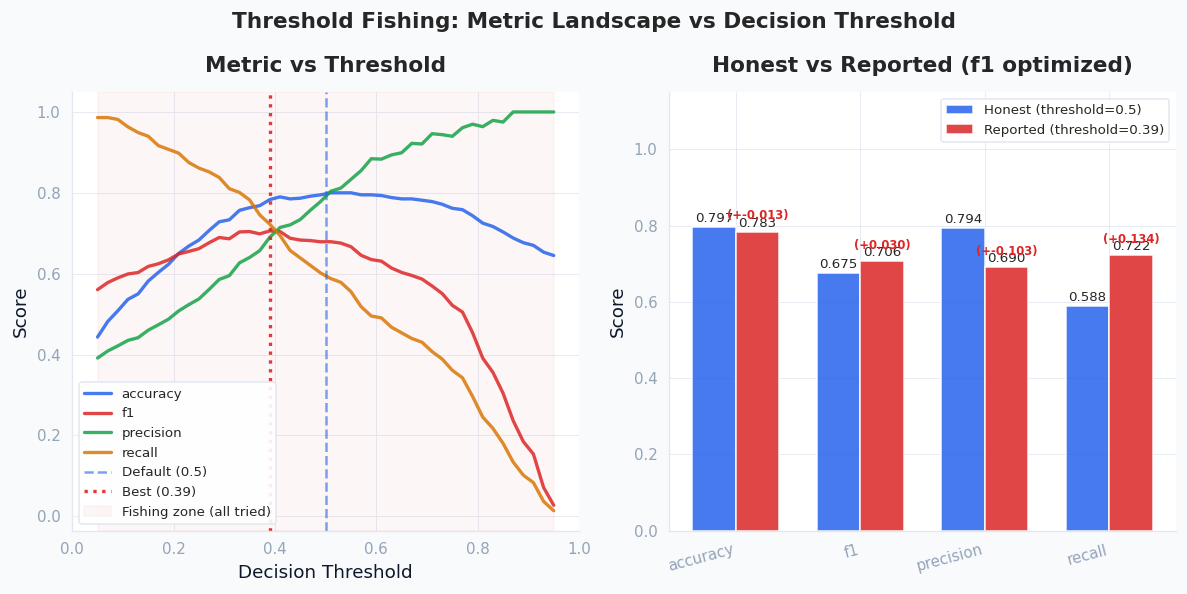

In [3]:
fig, _ = plot_threshold_landscape(
    report_tf,
    title='Threshold Fishing: Metric Landscape vs Decision Threshold',
)
plt.show()

---
## 2. Metric Cherry-Picking

### Khái niệm: Classification Metrics

Với binary classification, có nhiều metrics đánh giá model từ góc độ khác nhau:

| Metric | Công thức | Câu hỏi trả lời |
|---|---|---|
| Accuracy | $\frac{TP+TN}{TP+TN+FP+FN}$ | Model đúng bao nhiêu % tổng cases? |
| Precision | $\frac{TP}{TP+FP}$ | Khi predict positive, đúng bao nhiêu %? |
| Recall | $\frac{TP}{TP+FN}$ | Phát hiện được bao nhiêu % positives thật? |
| F1 | $\frac{2 \cdot P \cdot R}{P + R}$ | Harmonic mean của Precision và Recall |
| ROC-AUC | $\int_0^1 TPR(FPR)\, d(FPR)$ | Khả năng phân biệt 2 classes |

Mỗi metric phù hợp với một business context khác nhau. Không có metric nào là tốt nhất trong mọi tình huống.

### Metric Cherry-Picking là gì?

**Metric cherry-picking** xảy ra khi tính toán nhiều metrics nhưng chỉ báo cáo metric có giá trị cao nhất — giấu đi các metrics cho thấy model kém hơn.

Ví dụ thực tế: model có AUC = 0.72 (trung bình) nhưng Precision = 0.91 (cao vì threshold được chỉnh), data scientist chỉ report Precision.

Hệ quả: người đọc report có ấn tượng sai về chất lượng model.

### Matthews Correlation Coefficient (MCC)

**MCC** là metric ít bị cherry-pick nhất vì nó tính đến cả 4 ô trong confusion matrix:

$$\text{MCC} = \frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$$

MCC $\in [-1, 1]$:
- $+1$ → perfect prediction
- $0$ → không tốt hơn random
- $-1$ → hoàn toàn sai

MCC đặc biệt hữu ích với imbalanced data vì không bị inflate bởi majority class như Accuracy.

In [4]:
report_mc = cherry_pick_metric(baseline, report_top_n=1)

print('All metrics computed:')
for k, v in report_mc['all_metrics'].items():
    print(f'  {k:15s}: {v:.4f}')

print(f'\nReported (top 1)  : {report_mc["reported_metrics"]}')
print(f'Hidden metrics    : {report_mc["hidden_metrics"]}')
print(f'Reported avg      : {report_mc["reported_avg"]:.4f}')
print(f'Honest avg        : {report_mc["honest_avg"]:.4f}')
print(f'Inflation         : +{report_mc["inflation"]:.4f}')

All metrics computed:
  accuracy       : 0.7967
  f1             : 0.6755
  precision      : 0.7938
  recall         : 0.5880
  roc_auc        : 0.8484
  avg_precision  : 0.8061

Reported (top 1)  : {'roc_auc': 0.8484}
Hidden metrics    : {'avg_precision': 0.8061, 'accuracy': 0.7967, 'precision': 0.7938, 'f1': 0.6755, 'recall': 0.588}
Reported avg      : 0.8484
Honest avg        : 0.7514
Inflation         : +0.0970


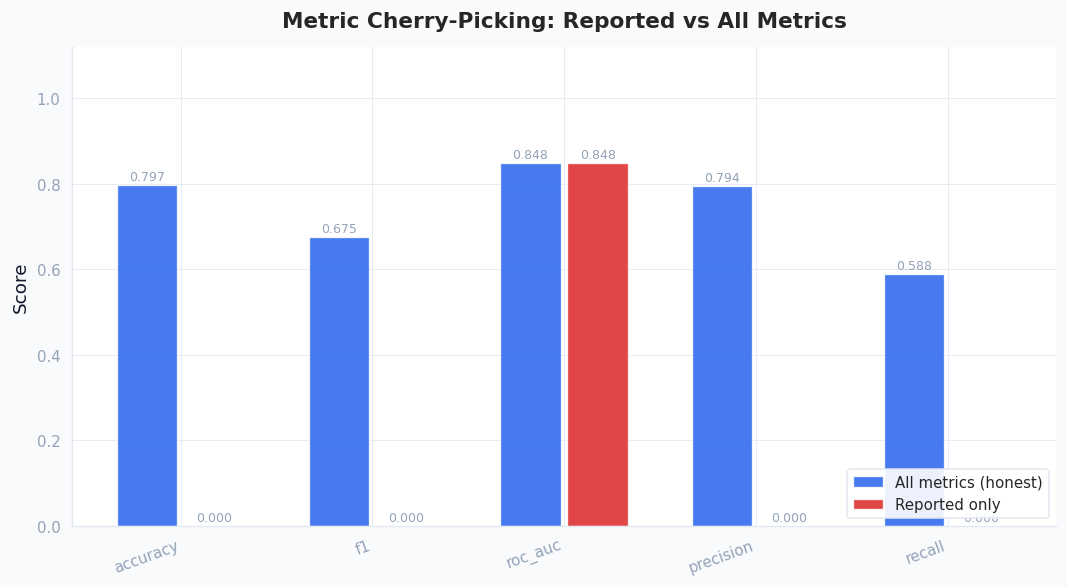

In [5]:
metrics_compare = {
    'All metrics (honest)': report_mc['all_metrics'],
    'Reported only':        report_mc['reported_metrics'],
}

fig, _ = plot_metric_comparison(
    metrics_compare,
    title='Metric Cherry-Picking: Reported vs All Metrics',
)
plt.show()

---
## 3. Test Set Reuse

### Khái niệm: Generalization và Overfitting

**Generalization** là khả năng model hoạt động tốt trên data chưa từng thấy. Mục tiêu của machine learning không phải là fit training data tốt, mà là **generalize** sang new data.

**Overfitting** xảy ra khi model học quá kỹ training data — bao gồm cả noise — đến mức performance trên training data rất cao nhưng trên test data thấp hơn nhiều.

$$\text{Generalization Gap} = \text{Train Score} - \text{Validation Score}$$

Gap lớn → model overfit.

### Test Set Reuse là gì?

**Test set reuse** xảy ra khi data scientist tune model nhiều lần dựa trên kết quả test set. Mỗi lần nhìn vào test score và điều chỉnh model, test set trở thành một dạng training signal.

Về mặt thống kê, nếu lặp lại $n$ lần, expected maximum test score tăng theo:

$$E[\text{max score after } n \text{ rounds}] \approx \mu + \sigma \cdot \Phi^{-1}\left(1 - \frac{1}{n}\right)$$

Trong đó $\mu$ là true generalization score, $\sigma$ là variance, $\Phi^{-1}$ là inverse CDF của normal distribution.

Đây là lý do benchmark competitions như Kaggle giới hạn số lần submission per day — mỗi lần submit là một lần "peek" vào test set.

### Cách phòng tránh đúng: Train / Validation / Test Split

Quy trình đúng cần ít nhất 3 tập:
- **Train set**: fit model
- **Validation set**: tune hyperparameters, chọn model
- **Test set**: evaluate một lần duy nhất ở cuối, không được nhìn trước

In [6]:
report_tsr = simulate_test_set_reuse(
    tt,
    model_type='logistic_regression',
    n_rounds=15,
)

print(f'Honest AUC (round 0) : {report_tsr["honest_auc_round0"]:.4f}')
print(f'Reported AUC (best)  : {report_tsr["reported_auc_best"]:.4f}')
print(f'Inflation            : +{report_tsr["inflation"]:.4f}')
print(f'Best round           : {report_tsr["best_round"]}')
print(f'Interpretation       : {report_tsr["interpretation"]}')

Honest AUC (round 0) : 0.8484
Reported AUC (best)  : 0.8485
Inflation            : +0.0001
Best round           : 7
Interpretation       : Test set reuse 15 rounds: honest AUC=0.8484 → reported AUC=0.8485 (+0.0001 inflation)


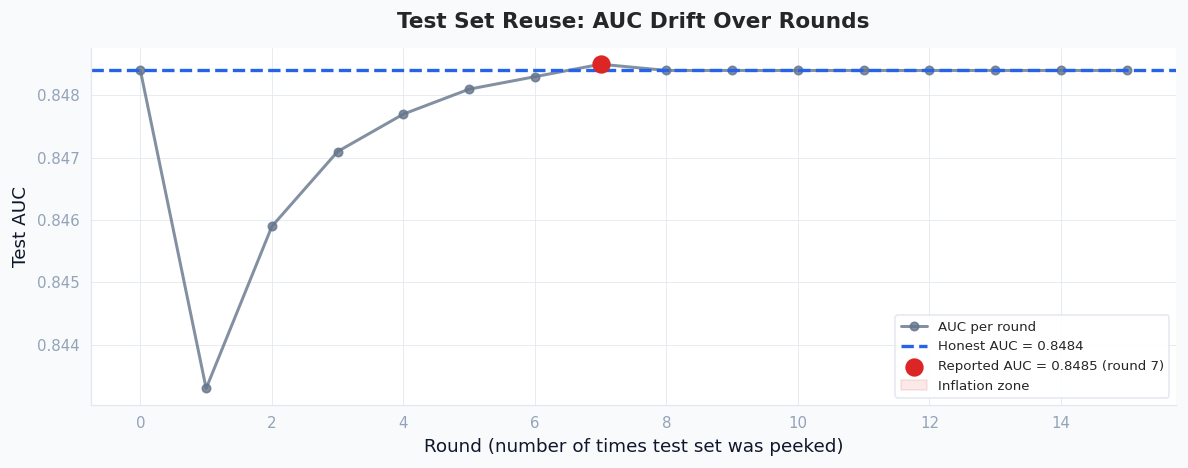

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))

rounds     = list(range(len(report_tsr['all_round_aucs'])))
aucs       = report_tsr['all_round_aucs']
honest_auc = report_tsr['honest_auc_round0']
best_auc   = report_tsr['reported_auc_best']
best_round = report_tsr['best_round']

ax.plot(rounds, aucs, 'o-', color='#64748B', lw=1.8, markersize=5, alpha=0.8, label='AUC per round')
ax.axhline(honest_auc, color='#2563EB', lw=2, linestyle='--', label=f'Honest AUC = {honest_auc:.4f}')
ax.scatter([best_round], [best_auc], color='#DC2626', s=100, zorder=5,
           label=f'Reported AUC = {best_auc:.4f} (round {best_round})')
ax.fill_between(rounds, honest_auc, aucs, where=[a > honest_auc for a in aucs],
                alpha=0.1, color='#DC2626', label='Inflation zone')

ax.set_xlabel('Round (number of times test set was peeked)')
ax.set_ylabel('Test AUC')
ax.set_title('Test Set Reuse: AUC Drift Over Rounds')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## 4. Hyperparameter Fishing

### Khái niệm: Hyperparameters

**Hyperparameters** là các tham số của model được đặt **trước khi** training, không được học từ data. Khác với parameters (weights) được tối ưu trong quá trình fit.

Ví dụ:
- Logistic Regression: `C` (regularization strength)
- Random Forest: `n_estimators`, `max_depth`, `min_samples_leaf`
- Gradient Boosting: `learning_rate`, `subsample`

### Hyperparameter Tuning đúng cách

Phương pháp chuẩn để tune hyperparameters:

**Cross-Validation:** chia train set thành $k$ folds, train trên $k-1$ folds, validate trên fold còn lại, lặp $k$ lần:

$$\text{CV Score} = \frac{1}{k} \sum_{i=1}^{k} \text{Score}(\text{model trained on folds} \neq i, \text{validated on fold } i)$$

**Quan trọng:** test set không được tham gia vào quá trình này.

### Hyperparameter Fishing là gì?

**Hyperparameter fishing** xảy ra khi thử nhiều hyperparameter configurations và đánh giá trực tiếp trên test set thay vì validation set. Config cho test score cao nhất được chọn và báo cáo.

Với $n$ configs thử, xác suất ít nhất một config cho kết quả cao bất thường trên test set tăng theo:

$$P(\max_i \text{Score}_i > \theta) = 1 - P(\text{Score}_i \leq \theta)^n$$

Với $n = 30$ configs và $\alpha = 0.05$: $P = 1 - 0.95^{30} \approx 0.79$ — tức là 79% khả năng ít nhất một config trông significant chỉ do may mắn.

In [8]:
# Biased: tune trực tiếp trên test set
report_hp_biased = fish_hyperparameters(
    tt,
    model_type='random_forest',
    n_random_trials=30,
    use_validation=False,   # biased
)

print('--- Biased (tuned on test set) ---')
print(f'Best eval AUC   : {report_hp_biased["best_eval_auc"]:.4f}  (eval = test set)')
print(f'Actual test AUC : {report_hp_biased["actual_test_auc"]:.4f}')
print(f'Eval inflation  : {report_hp_biased["eval_inflation"]:+.4f}')
print(f'Interpretation  : {report_hp_biased["interpretation"]}')

--- Biased (tuned on test set) ---
Best eval AUC   : 0.9153  (eval = test set)
Actual test AUC : 0.9153
Eval inflation  : +0.0000
Interpretation  : Biased search (30 trials): reported eval AUC=0.9153 → actual test AUC=0.9153 (eval inflation=+0.0000)


In [9]:
# Honest: tune trên validation set riêng
report_hp_honest = fish_hyperparameters(
    tt,
    model_type='random_forest',
    n_random_trials=30,
    use_validation=True,    # honest
)

print('--- Honest (tuned on validation set) ---')
print(f'Best eval AUC   : {report_hp_honest["best_eval_auc"]:.4f}  (eval = val set)')
print(f'Actual test AUC : {report_hp_honest["actual_test_auc"]:.4f}')
print(f'Eval inflation  : {report_hp_honest["eval_inflation"]:+.4f}')
print(f'Interpretation  : {report_hp_honest["interpretation"]}')

--- Honest (tuned on validation set) ---
Best eval AUC   : 0.9124  (eval = val set)
Actual test AUC : 0.9130
Eval inflation  : -0.0006
Interpretation  : Honest search (30 trials): reported eval AUC=0.9124 → actual test AUC=0.9130 (eval inflation=-0.0006)


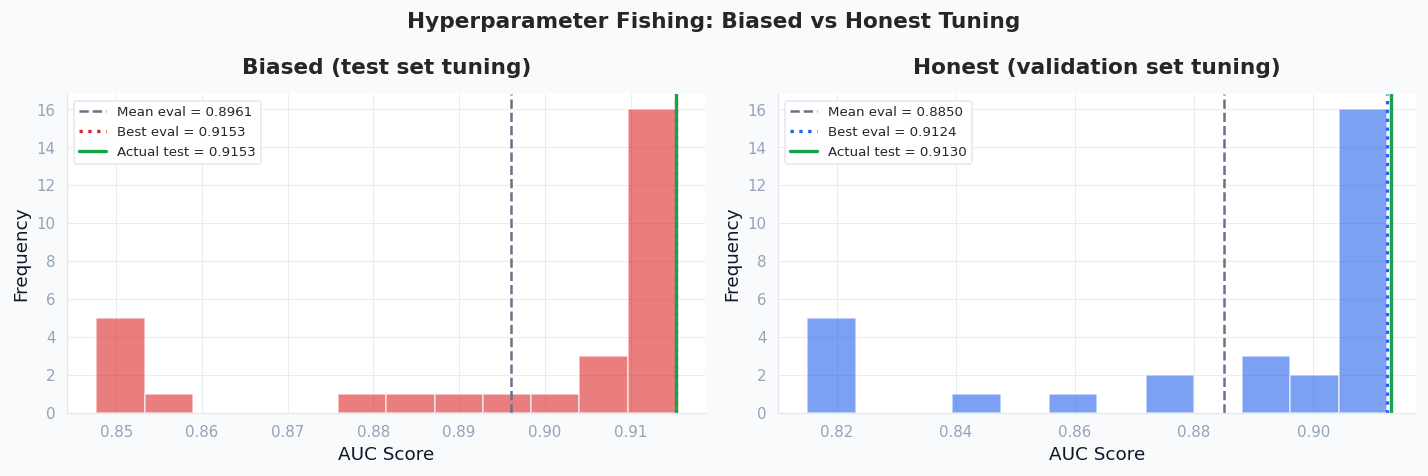

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, report, label, color in [
    (axes[0], report_hp_biased, 'Biased (test set tuning)',     '#DC2626'),
    (axes[1], report_hp_honest, 'Honest (validation set tuning)', '#2563EB'),
]:
    aucs = report['all_trial_aucs']
    ax.hist(aucs, bins=12, color=color, alpha=0.6, edgecolor='white')
    ax.axvline(report['mean_eval_auc'],   color='#64748B', lw=1.5, linestyle='--',
               label=f'Mean eval = {report["mean_eval_auc"]:.4f}')
    ax.axvline(report['best_eval_auc'],   color=color,     lw=2,   linestyle=':',
               label=f'Best eval = {report["best_eval_auc"]:.4f}')
    ax.axvline(report['actual_test_auc'], color='#16A34A', lw=2,
               label=f'Actual test = {report["actual_test_auc"]:.4f}')
    ax.set_xlabel('AUC Score')
    ax.set_ylabel('Frequency')
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.suptitle('Hyperparameter Fishing: Biased vs Honest Tuning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Selective Reporting

### Khái niệm: Publication Bias

**Publication bias** trong khoa học là xu hướng chỉ publish các kết quả positive hoặc significant, giấu đi các kết quả âm hay không có ý nghĩa. Trong data science, điều tương tự xảy ra ở cấp độ model reporting.

**Selective reporting** trong ML: train nhiều models với architectures, hyperparameters khác nhau, chỉ publish model tốt nhất mà không thông báo tổng số models đã thử.

### No Free Lunch Theorem

**No Free Lunch (NFL) Theorem** phát biểu rằng không có algorithm nào tốt hơn tất cả các algorithms khác trên mọi problems:

$$\sum_f P(d^m | f, m, a_1) = \sum_f P(d^m | f, m, a_2)$$

Trong đó $f$ là target function, $m$ là training set, $a_1, a_2$ là 2 algorithms.

Hệ quả thực tế: khi báo cáo "model A tốt hơn model B", phải chỉ rõ **trên dataset nào** và **với metric nào** — không thể generalize.

Selective reporting vi phạm điều này: chỉ report trên dataset và metric mà model A trông tốt.

### Multiple Comparisons Problem

Khi so sánh $k$ models cùng lúc, xác suất ít nhất một model trông significant chỉ do chance:

$$P(\text{at least one false positive}) = 1 - (1-\alpha)^k$$

Với $k=6$ models và $\alpha=0.05$: $P \approx 0.26$ — 26% khả năng có kết quả misleading chỉ do may mắn.

**Bonferroni correction** giảm significance level xuống $\alpha/k$ để control family-wise error rate.

In [11]:
report_sr = selective_reporting(
    tt,
    model_types=['logistic_regression', 'random_forest', 'gradient_boosting', 'decision_tree'],
    report_top_n=1,
)

print('All models trained:')
for model, auc in report_sr['all_model_aucs'].items():
    marker = '  <-- REPORTED' if model in report_sr['reported_models'] else ''
    print(f'  {model:25s}: AUC = {auc:.4f}{marker}')

print(f'\nReported avg AUC : {report_sr["reported_avg_auc"]:.4f}')
print(f'Honest avg AUC   : {report_sr["honest_avg_auc"]:.4f}')
print(f'Inflation        : +{report_sr["inflation"]:.4f}')
print(f'Interpretation   : {report_sr["interpretation"]}')

All models trained:
  logistic_regression      : AUC = 0.8484
  random_forest            : AUC = 0.9110
  gradient_boosting        : AUC = 0.9237  <-- REPORTED
  decision_tree            : AUC = 0.8334

Reported avg AUC : 0.9237
Honest avg AUC   : 0.8791
Inflation        : +0.0446
Interpretation   : Trained 4 models, reported top 1: AUC=0.9237 vs honest avg=0.8791 (+0.0446)


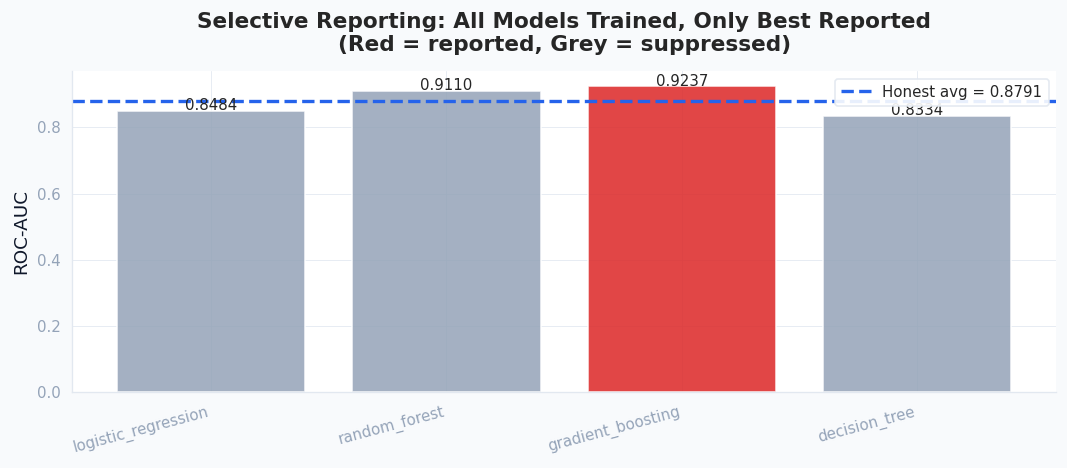

In [12]:
all_aucs      = report_sr['all_model_aucs']
reported_keys = set(report_sr['reported_models'].keys())

fig, ax = plt.subplots(figsize=(9, 4))

colors = ['#DC2626' if m in reported_keys else '#94A3B8' for m in all_aucs]
bars   = ax.bar(range(len(all_aucs)), list(all_aucs.values()),
                color=colors, alpha=0.85, edgecolor='white')

ax.axhline(report_sr['honest_avg_auc'], color='#2563EB', lw=2,
           linestyle='--', label=f'Honest avg = {report_sr["honest_avg_auc"]:.4f}')

for bar, v in zip(bars, all_aucs.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{v:.4f}', ha='center', fontsize=9)

ax.set_xticks(range(len(all_aucs)))
ax.set_xticklabels(list(all_aucs.keys()), rotation=15, ha='right')
ax.set_ylabel('ROC-AUC')
ax.set_title('Selective Reporting: All Models Trained, Only Best Reported\n(Red = reported, Grey = suppressed)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Overfitting vs Generalization

### Khái niệm: Bias-Variance Tradeoff

**Bias-Variance Tradeoff** là một trong những nguyên lý cơ bản nhất của machine learning. Expected prediction error có thể được decompose thành:

$$\text{Expected Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}$$

Trong đó:
- **Bias**: error do model quá đơn giản, không capture được patterns trong data (underfitting)
- **Variance**: error do model quá phức tạp, sensitive với noise trong training data (overfitting)
- **Irreducible Noise**: error do bản thân data có noise, không thể giảm bằng model tốt hơn

Model phức tạp → Variance cao, Bias thấp
Model đơn giản → Variance thấp, Bias cao

### Overconfidence qua Overfitting

Một model overfit có train accuracy rất cao nhưng test accuracy thấp hơn. Nếu data scientist chỉ báo cáo train accuracy, đây là một dạng overconfidence bias đặc biệt nguy hiểm vì:
1. Không cần làm gì sai — chỉ cần không báo cáo đúng
2. Model trông tốt trên paper nhưng fail hoàn toàn khi deploy

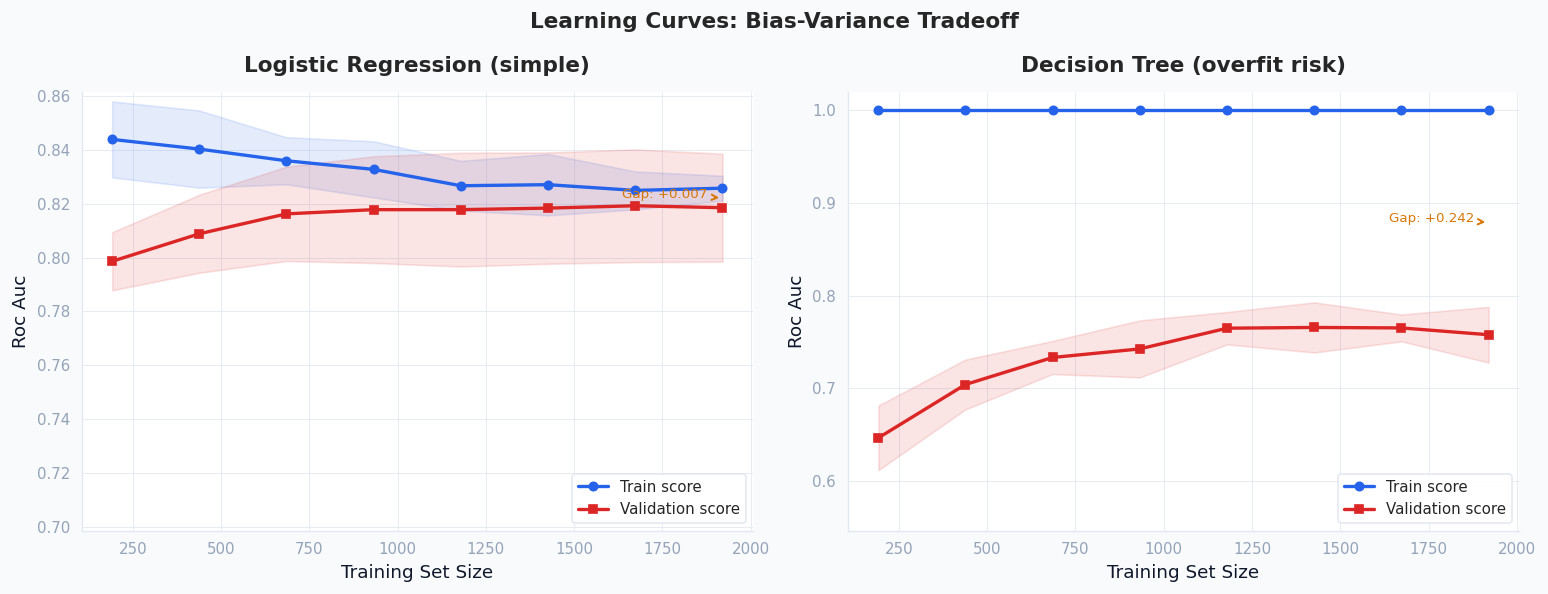

In [13]:
from src.models.baseline_model import build_model

# So sanh learning curve: model don gian vs overfit
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models_to_compare = [
    ('Logistic Regression (simple)', build_model('logistic_regression', scale_features=True), axes[0]),
    ('Decision Tree (overfit risk)',  build_model('decision_tree', scale_features=False, max_depth=None, min_samples_leaf=1), axes[1]),
]

for label, pipeline, ax in models_to_compare:
    from src.visualization.plots import plot_learning_curve
    plot_learning_curve(
        pipeline, tt.X_train, tt.y_train,
        title=label,
        scoring='roc_auc',
        ax=ax,
    )

plt.suptitle('Learning Curves: Bias-Variance Tradeoff', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Aggregate Analysis

### Khái niệm: Statistical Significance vs Practical Significance

Khi đánh giá tác động của bias, cần phân biệt 2 loại significance:

**Statistical significance**: liệu sự khác biệt có thể do chance không?
- Đo bằng p-value từ hypothesis test (McNemar's test, t-test...)
- p < 0.05 → unlikely to be by chance

**Practical significance**: sự khác biệt có đủ lớn để quan tâm trong thực tế không?
- Đo bằng effect size (Cohen's d, Cohen's g...)
- Một sự khác biệt có thể statistically significant nhưng practically negligible

**Cohen's g** (dùng cho McNemar's test):

$$g = \left| \frac{b}{b+c} - 0.5 \right|$$

Trong đó $b, c$ là hai ô off-diagonal của contingency table. $g < 0.1$ = small, $g < 0.3$ = medium, $g \geq 0.3$ = large.

In [14]:
all_selection_results = []

strategies = [
    ('threshold_fishing',     {'objective': 'f1'}),
    ('metric_cherry_picking', {'report_top_n': 1}),
    ('test_set_reuse',        {'n_rounds': 10}),
    ('hyperparameter_fishing',{'n_random_trials': 20}),
    ('selective_reporting',   {'report_top_n': 1}),
]

for strategy, kwargs in strategies:
    result = simulate_biased_selection(tt, strategy=strategy, **kwargs)
    all_selection_results.append(result)
    print(f'[{strategy:30s}] severity={result.bias_report.get("interpretation", "")[:60]}')

[threshold_fishing             ] severity=Chọn threshold=0.39 trên test set: f1=0.7059 thay vì honest 
[metric_cherry_picking         ] severity=Báo cáo top-1 metric ({'roc_auc': 0.8484}) — impression infl
[test_set_reuse                ] severity=Test set reuse 10 rounds: honest AUC=0.8484 → reported AUC=0
[hyperparameter_fishing        ] severity=Biased search (20 trials): reported eval AUC=0.8484 → actual
[selective_reporting           ] severity=Trained 4 models, reported top 1: AUC=0.9237 vs honest avg=0


In [15]:
# Tong hop severity
print('\n=== Model Selection Bias Summary ===')
for r in all_selection_results:
    honest   = r.bias_report.get('honest_score') or r.bias_report.get('honest_avg') or r.bias_report.get('honest_avg_auc')
    reported = r.bias_report.get('reported_score') or r.bias_report.get('reported_avg') or r.bias_report.get('reported_avg_auc')
    if honest and reported:
        inflation = reported - honest
        print(f'  {r.strategy:30s}: honest={honest:.4f}, reported={reported:.4f}, inflation={inflation:+.4f}')


=== Model Selection Bias Summary ===
  metric_cherry_picking         : honest=0.7514, reported=0.8484, inflation=+0.0970
  selective_reporting           : honest=0.8791, reported=0.9237, inflation=+0.0446


---
## 8. Summary

Notebook này đã trình bày 5 dạng bias trong model selection — tất cả đều xảy ra trên dữ liệu sạch:

| Strategy | Cơ chế bias | Metric bị inflate |
|---|---|---|
| Threshold fishing | Chọn threshold trên test set | F1, Precision, Recall |
| Metric cherry-picking | Chỉ report metric cao nhất | Phụ thuộc metric được chọn |
| Test set reuse | Tune model dựa trên test score | AUC, Accuracy |
| Hyperparameter fishing | Tune trực tiếp trên test set | AUC |
| Selective reporting | Giấu models kém, chỉ publish best | AUC, Accuracy |

Điểm chung của tất cả các strategies này: **thông tin từ test set rò rỉ vào quá trình xây dựng model**, khiến test set không còn là honest evaluation nữa.

Notebook 04 sẽ tổng hợp kết quả từ tất cả experiments và visualize toàn bộ bức tranh tác động của behavioral bias.